# Three Insurance Strategies Under Market Cycles

## Comparing Static, Size-Adaptive, and Fully Adaptive Approaches

This notebook compares three insurance purchasing strategies for a manufacturingcompany over a 25-year horizon under stochastic market cycles:

1. **Static** — Insurance optimized once for normal-market conditions at the initial company size. The retention and limit are never updated.
2. **Size-Adaptive** — Retention and limits are re-optimized each year for the current company size, always assuming a normal market (loss ratio = 0.70).
3. **Fully Adaptive** — Re-optimized each year for *both* current company size and the prevailing market cycle (Soft / Normal / Hard).Market cycles follow a 3-state Markov chain calibrated to underwriting-cycleliterature (Hamilton, 1989; Cummins & Outreville, 1987).

All three companiesface identical loss realizations via **Common Random Numbers (CRN)**, isolatingthe pure strategy effect from sampling noise.

**Key insight from ergodic economics**: the *time-average* growth rate — not theensemble average — determines long-run wealth. Adapting to market conditionscompounds small annual advantages into large terminal-wealth differences.-

**Audience**: Actuaries, CFOs, Risk Managers

In [1]:
"""Google Colab setup: mount Drive and install package dependencies.

Run this cell first. If prompted to restart the runtime, do so, then re-run all cells.
This cell is a no-op when running locally.
"""
import sys, os
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')

    NOTEBOOK_DIR = '/content/drive/My Drive/Colab Notebooks/ei_notebooks/optimization'

    os.chdir(NOTEBOOK_DIR)
    if NOTEBOOK_DIR not in sys.path:
        sys.path.append(NOTEBOOK_DIR)

    !pip install ergodic-insurance -q 2>&1 | tail -3
    print('\nSetup complete. If you see numpy/scipy import errors below,')
    print('restart the runtime (Runtime > Restart runtime) and re-run all cells.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Setup complete. If you see numpy/scipy import errors below,
restart the runtime (Runtime > Restart runtime) and re-run all cells.


## Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from scipy.stats import norm as sp_norm, lognorm as sp_lognorm
from scipy.interpolate import interp1d
from multiprocessing import Pool, cpu_count
import warnings, logging, time, os

warnings.filterwarnings("ignore")
logging.getLogger("ergodic_insurance").setLevel(logging.ERROR)

from ergodic_insurance.visualization.core import (
    set_wsj_style, WSJ_COLORS, COLOR_SEQUENCE, WSJFormatter,
)
from ergodic_insurance.config import ManufacturerConfig
from ergodic_insurance.manufacturer import WidgetManufacturer
from ergodic_insurance.insurance_program import (
    EnhancedInsuranceLayer, InsuranceProgram,
)
from ergodic_insurance.loss_distributions import (
    ManufacturingLossGenerator, LognormalLoss, ParetoLoss,
)
from ergodic_insurance.insurance_pricing import LayerPricer

SEED = 20260223
np.random.seed(SEED)

N_CORES = cpu_count()
print(f"Using {N_CORES} cores for parallel computation")

Using 44 cores for parallel computation


## Part I — Company Configuration

Baseline manufacturing company. All three strategies start from the same initial conditions; differences emerge only from insurance-purchasing decisions.

In [3]:
# --- Economic Parameters ---
ATR = 1.75                 # Asset turnover ratio
OPERATING_MARGIN = 0.15   # 15% EBIT margin before insurable losses
REV_VOL = 0.50            # Revenue volatility
INITIAL_ASSETS = 10_000_000
TAX_RATE = 0.25
RETENTION_RATIO = 0.70    # 70% of earnings retained for growth

mfg_config = ManufacturerConfig(
    initial_assets=INITIAL_ASSETS,
    asset_turnover_ratio=ATR,
    base_operating_margin=OPERATING_MARGIN,
    tax_rate=TAX_RATE,
    retention_ratio=RETENTION_RATIO,
)

revenue = INITIAL_ASSETS * ATR
ebit = revenue * OPERATING_MARGIN
print("=" * 60)
print("MANUFACTURING COMPANY PROFILE")
print("=" * 60)
print(f"Total Assets:          ${INITIAL_ASSETS:>14,.0f}")
print(f"Annual Revenue:        ${revenue:>14,.0f}")
print(f"Operating Income:      ${ebit:>14,.0f}")
print(f"Operating Margin:      {OPERATING_MARGIN:>14.1%}")
print(f"Asset Turnover:        {ATR:>14.1f}x")
print(f"Revenue Volatility:    {REV_VOL:>14.2f}")
print(f"Tax Rate:              {TAX_RATE:>13.1%}")
print(f"Retention Ratio:       {RETENTION_RATIO:>13.1%}")
print("=" * 60)

MANUFACTURING COMPANY PROFILE
Total Assets:          $    10,000,000
Annual Revenue:        $    17,500,000
Operating Income:      $     2,625,000
Operating Margin:               15.0%
Asset Turnover:                   1.8x
Revenue Volatility:              0.50
Tax Rate:                      25.0%
Retention Ratio:               70.0%


## Part II — Loss Model & Insurance Pricing

Three-component compound-Poisson loss model (attritional, large, catastrophic) with sub-linear frequency scaling in revenue. Insurance towers are priced analytically via Limited Expected Values (LEVs) so that rate-on-line decreases naturally as the retention rises.

In [4]:
REFERENCE_REVENUE = ATR * INITIAL_ASSETS
FREQ_SCALING_EXPONENT = 0.75

# --- Loss Model Parameters ---
ATTR_BASE_FREQ = 5;       ATTR_SEV_MEAN = 10_000;      ATTR_SEV_CV = 3
LG_BASE_FREQ   = 1.75;      LG_SEV_MEAN   = 375_000;     LG_SEV_CV   = 1.5
CAT_BASE_FREQ  = 0.15;     CAT_SEV_ALPHA = 2.01;         CAT_SEV_XM  = 1_500_000

LOSS_PARAMS = dict(
    attritional_params=dict(base_frequency=ATTR_BASE_FREQ,
                            severity_mean=ATTR_SEV_MEAN, severity_cv=ATTR_SEV_CV,
                            revenue_scaling_exponent=FREQ_SCALING_EXPONENT,
                            reference_revenue=REFERENCE_REVENUE),
    large_params=dict(base_frequency=LG_BASE_FREQ,
                      severity_mean=LG_SEV_MEAN, severity_cv=LG_SEV_CV,
                      revenue_scaling_exponent=FREQ_SCALING_EXPONENT,
                      reference_revenue=REFERENCE_REVENUE),
    catastrophic_params=dict(base_frequency=CAT_BASE_FREQ,
                             severity_alpha=CAT_SEV_ALPHA, severity_xm=CAT_SEV_XM,
                             revenue_scaling_exponent=FREQ_SCALING_EXPONENT,
                             reference_revenue=REFERENCE_REVENUE),
)

# Lognormal distribution parameters
attr_var = np.log(1 + ATTR_SEV_CV**2)
attr_mu  = np.log(ATTR_SEV_MEAN) - attr_var / 2
attr_sig = np.sqrt(attr_var)

lg_var = np.log(1 + LG_SEV_CV**2)
lg_mu  = np.log(LG_SEV_MEAN) - lg_var / 2
lg_sig = np.sqrt(lg_var)

# --- Vectorized LEV functions (Klugman, Panjer & Willmot, Ch. 5) ---
def lev_lognormal(d, mu, sigma):
    d = np.asarray(d, dtype=float)
    safe_d = np.maximum(d, 1e-10)
    mean = np.exp(mu + sigma**2 / 2)
    z1 = (np.log(safe_d) - mu - sigma**2) / sigma
    z2 = (np.log(safe_d) - mu) / sigma
    return mean * sp_norm.cdf(z1) + d * (1 - sp_norm.cdf(z2))

def lev_pareto(d, alpha, xm):
    d = np.asarray(d, dtype=float)
    safe_d = np.maximum(d, xm)
    return np.where(
        d <= xm, d,
        alpha * xm / (alpha - 1) * (1 - (xm / safe_d)**(alpha - 1))
        + d * (xm / safe_d)**alpha
    )

def expected_retained(retention, revenue):
    """E[losses below retention] per year, vectorized."""
    s = (revenue / REFERENCE_REVENUE) ** FREQ_SCALING_EXPONENT
    return (ATTR_BASE_FREQ * s * lev_lognormal(retention, attr_mu, attr_sig)
          + LG_BASE_FREQ   * s * lev_lognormal(retention, lg_mu, lg_sig)
          + CAT_BASE_FREQ  * s * lev_pareto(retention, CAT_SEV_ALPHA, CAT_SEV_XM))

def expected_insured(retention, max_limit, revenue):
    """E[losses in the tower (retention, max_limit)] per year, vectorized."""
    s = (revenue / REFERENCE_REVENUE) ** FREQ_SCALING_EXPONENT
    lev_lim = (ATTR_BASE_FREQ * s * lev_lognormal(max_limit, attr_mu, attr_sig)
             + LG_BASE_FREQ   * s * lev_lognormal(max_limit, lg_mu, lg_sig)
             + CAT_BASE_FREQ  * s * lev_pareto(max_limit, CAT_SEV_ALPHA, CAT_SEV_XM))
    return lev_lim - expected_retained(retention, revenue)

def compute_premium(retention, max_limit, loss_ratio, revenue):
    """Annual tower premium = E[insured] / loss_ratio, vectorized."""
    ins = expected_insured(retention, max_limit, revenue)
    return np.where(max_limit > retention, ins / loss_ratio, 0.0)

def expected_total_losses(revenue):
    s = (revenue / REFERENCE_REVENUE) ** FREQ_SCALING_EXPONENT
    a_mean = np.exp(attr_mu + attr_var / 2)
    l_mean = np.exp(lg_mu + lg_var / 2)
    c_mean = CAT_SEV_ALPHA * CAT_SEV_XM / (CAT_SEV_ALPHA - 1)
    return s * (ATTR_BASE_FREQ * a_mean + LG_BASE_FREQ * l_mean + CAT_BASE_FREQ * c_mean)

# Quick validation
_el = expected_total_losses(REFERENCE_REVENUE)
_oi = INITIAL_ASSETS * ATR * OPERATING_MARGIN
print(f"Loss model validation:")
print(f"  Expected annual loss:  ${_el:>12,.0f}")
print(f"  Operating income:      ${_oi:>12,.0f}")
print(f"  Loss / Income ratio:   {_el / _oi:.0%}")

Loss model validation:
  Expected annual loss:  $   1,154,022
  Operating income:      $   2,625,000
  Loss / Income ratio:   44%


## Part III — Market Cycle Model

A 3-state Markov chain drives the underwriting cycles. The transition matrix is calibrated so that soft markets are moderately persistent, normal markets are the most common, and hard markets are sticky once entered, matching the stylized facts in Hamilton (1989) and Cummins & Outreville (1987). Each state sets an insurance **loss ratio** (which drives premium loading) without affecting the **loss-frequency multiplier** (although there is well-documented correlation between lax underwriting in soft markets and higher loss emergence, we are dealing with a single company, and assume its loss control remains in place regardless of the market. Experiment can be run with custom `MARKET_FREQ_MULT` to simulate dynamic market frequency):

In [5]:
MARKET_NAMES = ['Soft', 'Normal', 'Hard']
MARKET_LR = np.array([0.90, 0.70, 0.60])
MARKET_FREQ_MULT = np.array([1.00, 1.00, 1.00])  # Loss-frequency multiplier by state

# Transition matrix (rows = from, columns = to)
P_TRANSITION = np.array([
    [0.70, 0.25, 0.05],   # From Soft
    [0.20, 0.60, 0.20],   # From Normal
    [0.05, 0.55, 0.40],   # From Hard
])

# Stationary distribution
eigvals, eigvecs = np.linalg.eig(P_TRANSITION.T)
stat_idx = np.argmin(np.abs(eigvals - 1.0))
stationary = np.real(eigvecs[:, stat_idx])
stationary /= stationary.sum()

print("Transition matrix P:")
print(pd.DataFrame(P_TRANSITION, index=MARKET_NAMES, columns=MARKET_NAMES))
print(f"\nStationary distribution: "
      + ", ".join(f"{n}={p:.1%}" for n, p in zip(MARKET_NAMES, stationary)))
print(f"Long-run expected LR: {stationary @ MARKET_LR:.3f}")

# --- Simulation parameters ---
N_YEARS = 50
N_SCENARIOS = 100_000
INITIAL_MARKET = 1   # Start in Normal

def simulate_market_chain(n_years, n_scenarios, initial=1, seed=42):
    """Simulate Markov chain paths.  Returns (n_scenarios, n_years) int array."""
    rng = np.random.default_rng(seed)
    states = np.zeros((n_scenarios, n_years), dtype=np.int32)
    states[:, 0] = initial
    cumP = np.cumsum(P_TRANSITION, axis=1)
    for t in range(1, n_years):
        u = rng.random(n_scenarios)
        for s in range(3):
            mask = states[:, t - 1] == s
            states[mask, t] = np.searchsorted(cumP[s], u[mask])
    return states

market_states = simulate_market_chain(N_YEARS, N_SCENARIOS, INITIAL_MARKET, seed=SEED)
print(f"\nSimulated {N_SCENARIOS:,} scenarios × {N_YEARS} years")
# Time-averaged state fractions
for s_idx, name in enumerate(MARKET_NAMES):
    frac = (market_states == s_idx).mean()
    print(f"  {name:>6s} fraction: {frac:.1%} (stationary: {stationary[s_idx]:.1%})")

Transition matrix P:
        Soft  Normal  Hard
Soft    0.70    0.25  0.05
Normal  0.20    0.60  0.20
Hard    0.05    0.55  0.40

Stationary distribution: Soft=34.4%, Normal=47.0%, Hard=18.5%
Long-run expected LR: 0.750

Simulated 100,000 scenarios × 50 years
    Soft fraction: 33.1% (stationary: 34.4%)
  Normal fraction: 48.6% (stationary: 47.0%)
    Hard fraction: 18.3% (stationary: 18.5%)


## Part IV — Bellman Optimization (Dual-Objective HJB)

For each *(company size, market state)* pair we solve a **dual-objective** one-period Bellman equation that blends **growth maximisation** (Sharpe/Kelly) with **ruin aversion**:

$$\max_{d,\,\ell}\;(1-\alpha)\;\underbrace{\mathbb{E}\!\left[\ln\frac{W_{t+1}}{W_t}\,\bigg|\,\text{survive}\right]}_{\text{conditional growth (Sharpe)}}+\;\alpha\;\underbrace{N\ln P(\text{survive}_1)}_{\text{N-year ruin penalty}}$$

where $\alpha$ = `RUIN_AVERSION` and $N$ = `N_YEARS`. The first term maximises risk-adjusted growth among survivors; the second penalises annual ruin probability *scaled by the planning horizon*, so that a 0.2% annual risk — negligible over one year — registers as $50 \times \ln(0.998) \approx -0.10$, comparable to the 10% growth rate itself.

| `RUIN_AVERSION` | Behaviour |
|---|---|
| 0.0 | Pure Kelly criterion (log utility) — maximise time-average growth |
| **0.5** | **Equal weight to Sharpe and lifetime ruin reduction** |
| 1.0 | Pure survival maximisation — buy maximum coverage regardless of cost |

Under multiplicative dynamics with $\alpha=0$, the myopic solution is globally optimal (Kelly criterion). For $\alpha>0$ the ruin penalty makes the objective sensitive to the planning horizon through $N$, but the one-period Bellman lookup remains a good approximation because survival probability is predominantly a function of current wealth and tower structure.

**Full accounting**: Each candidate tower is evaluated by running `WidgetManufacturer` through a single period. Per-scenario revenue shocks (`REV_VOL`) are applied to loss scaling, matching the CRN simulation; premiums are set at expected revenue (locked at policy inception). This captures NOL carryforward (IRC §172), LAE at claim inception (ASC 944-40), deferred tax assets/liabilities, solvency checks (ASC 205-40), and multi-year claim payment schedules — all effects that were previously approximated by the vectorized proxy.

The premium each company pays is determined by the **actual** market loss ratio (set by insurers); the company's decision variable is the tower *structure* (retention $d$ and limit $\ell$). The Fully Adaptive strategy knows the true market state; Size-Adaptive always assumes Normal market.

In [6]:
N_OPT_SCENARIOS = 1_000
RUIN_AVERSION = 0.15  # 0 = pure Kelly/Sharpe, 1 = pure survival maximisation

# --- Accounting constants (match ManufacturerConfig defaults) ---
LAE_RATIO = 0.12               # Combined ALAE + ULAE as fraction of retained losses
LETTER_OF_CREDIT_RATE = 0.015  # Annual cost of collateral on retention

# --- Worker: generate one scenario's losses at reference revenue ---
def _gen_opt_losses(seed_val):
    gen = ManufacturingLossGenerator(**LOSS_PARAMS, seed=seed_val)
    evts, _ = gen.generate_losses(duration=1.0, revenue=REFERENCE_REVENUE)
    return [e.amount for e in evts]

# --- Generate optimisation loss pool (parallel) ---
print("Generating optimisation loss pool ...")
print(f"  Objective blend: {1-RUIN_AVERSION:.0%} Sharpe + "
      f"{RUIN_AVERSION:.0%} ruin penalty (horizon N={N_YEARS})")
print(f"  Full WidgetManufacturer accounting (NOL, LAE, solvency, DTA/DTL)")
t0 = time.time()
opt_ss = np.random.SeedSequence(SEED + 100)
opt_children = opt_ss.spawn(N_OPT_SCENARIOS)

_seed_list = [int(opt_children[i].generate_state(1)[0] % (2**31))
              for i in range(N_OPT_SCENARIOS)]

with Pool(N_CORES) as pool:
    _opt_events = pool.map(_gen_opt_losses, _seed_list, chunksize=64)

_max_ev = max((len(a) for a in _opt_events), default=0)

opt_loss_amounts = np.zeros((N_OPT_SCENARIOS, _max_ev))
for i, a in enumerate(_opt_events):
    opt_loss_amounts[i, :len(a)] = a
del _opt_events

# Revenue shocks for optimisation (match CRN simulation logic)
opt_rev_rng = np.random.default_rng(np.random.SeedSequence(SEED + 150))
opt_rev_shocks = opt_rev_rng.standard_normal(N_OPT_SCENARIOS)

print(f"  {N_OPT_SCENARIOS:,} scenarios, up to {_max_ev} events/yr  ({time.time()-t0:.1f}s)")
print(f"  Revenue shocks included (REV_VOL={REV_VOL})")

# --- Optimisation grids ---
WEALTH_GRID = np.geomspace(500_000, 1e9, 14)
RET_GRID    = np.array([10_000, 25_000, 50_000, 100_000, 150_000,
                        200_000, 250_000, 350_000, 500_000, 750_000,
                         1e6, 1.5e6, 2e6, 2.5e6, 3e6, 4e6, 5e6,
                        7.5e6, 10e6, 15e6, 20e6, 25e6, 35e6,
                        50e6, 75e6, 100e6])
LIM_GRID    = np.array([500_000, 750_000, 1e6, 2e6, 3.5e6,
                        5e6, 7.5e6, 10e6, 15e6, 20e6, 25e6, 35e6,
                        50e6, 75e6, 100e6, 150e6, 200e6, 250e6, 350e6,
                        400e6, 500e6])

n_combos = sum(1 for r in RET_GRID for l in LIM_GRID if l > r)
print(f"  Grid: {len(WEALTH_GRID)} wealth × 3 states × {n_combos} (ret,lim) combos")
print(f"  Total manufacturer create+step cycles: "
      f"~{3 * len(WEALTH_GRID) * (n_combos + 1) * N_OPT_SCENARIOS / 1e6:.1f}M")

# --- Worker: full-accounting grid search for one (state, wealth) pair ---
def _optimize_one_pair_accounting(args):
    """Full-accounting grid search for one (state, wealth) pair.

    Creates a shared ManufacturerConfig once, then for each (ret, lim) combo
    loops over N_OPT_SCENARIOS single-period WidgetManufacturer evaluations.
    Revenue shocks vary per-scenario to match the CRN simulation logic.
    """
    s_idx, w_idx, w, lr, fm, loss_pool, rev_shocks = args

    n_sc = loss_pool.shape[0]
    rev_exp = max(w * ATR, 1.0)  # expected revenue (for premium, set at inception)

    # Per-scenario realised revenue (matches CRN simulation)
    rev_realised = np.maximum(
        w * ATR * np.exp(REV_VOL * rev_shocks - 0.5 * REV_VOL**2), 1.0)
    # Per-scenario loss scaling
    scales = (rev_realised / REFERENCE_REVENUE) ** FREQ_SCALING_EXPONENT * fm
    scaled = loss_pool * scales[:, None]  # (n_sc, max_events)

    config = ManufacturerConfig(
        initial_assets=float(w),
        asset_turnover_ratio=ATR,
        base_operating_margin=OPERATING_MARGIN,
        tax_rate=TAX_RATE,
        retention_ratio=RETENTION_RATIO,
        nol_carryforward_enabled=True,
        lae_ratio=LAE_RATIO,
    )

    best_g, best_r, best_l = -np.inf, RET_GRID[0], LIM_GRID[-1]

    for r in RET_GRID:
        for l in LIM_GRID:
            if l <= r:
                continue
            layer_cap = l - r
            prem = float(compute_premium(r, l, lr, rev_exp))

            n_survive = 0
            sum_log_g = 0.0

            for i in range(n_sc):
                mfg = WidgetManufacturer.create_fresh(config, simulation_mode=True)
                mfg.record_insurance_premium(prem, is_annual=False)

                for j in range(scaled.shape[1]):
                    loss = float(scaled[i, j])
                    if loss <= 0:
                        break
                    recovery = max(0.0, min(loss - r, layer_cap))
                    mfg.process_insurance_claim(
                        claim_amount=loss, insurance_recovery=recovery)

                mfg.step(apply_stochastic=False)
                eq = float(mfg.equity)
                if eq > 0:
                    n_survive += 1
                    sum_log_g += np.log(eq / w)

            if n_survive == 0:
                g = -np.inf
            else:
                cond_g = sum_log_g / n_survive
                p_s = n_survive / n_sc
                ruin_pen = N_YEARS * np.log(p_s) if p_s < 1.0 else 0.0
                g = (1 - RUIN_AVERSION) * cond_g + RUIN_AVERSION * ruin_pen

            if g > best_g:
                best_g, best_r, best_l = g, r, l

    # Self-insurance baseline (no insurance recovery)
    n_survive_si = 0
    sum_log_g_si = 0.0
    for i in range(n_sc):
        mfg = WidgetManufacturer.create_fresh(config, simulation_mode=True)
        # No premium, no recovery
        for j in range(scaled.shape[1]):
            loss = float(scaled[i, j])
            if loss <= 0:
                break
            mfg.process_insurance_claim(claim_amount=loss, insurance_recovery=0.0)
        mfg.step(apply_stochastic=False)
        eq = float(mfg.equity)
        if eq > 0:
            n_survive_si += 1
            sum_log_g_si += np.log(eq / w)

    if n_survive_si == 0:
        selfins_g = -np.inf
    else:
        cond_g_si = sum_log_g_si / n_survive_si
        p_s_si = n_survive_si / n_sc
        ruin_pen_si = N_YEARS * np.log(p_s_si) if p_s_si < 1.0 else 0.0
        selfins_g = (1 - RUIN_AVERSION) * cond_g_si + RUIN_AVERSION * ruin_pen_si

    return s_idx, w_idx, best_r, best_l, best_g, selfins_g

# --- Parallel grid search ---
tasks = []
for s_idx in range(3):
    lr = float(MARKET_LR[s_idx])
    fm = float(MARKET_FREQ_MULT[s_idx])
    for w_idx, w in enumerate(WEALTH_GRID):
        tasks.append((s_idx, w_idx, float(w), lr, fm, opt_loss_amounts, opt_rev_shocks))

optimal_ret = np.zeros((3, len(WEALTH_GRID)))
optimal_lim = np.zeros((3, len(WEALTH_GRID)))
optimal_gro = np.zeros((3, len(WEALTH_GRID)))
selfinsure_gro = np.zeros((3, len(WEALTH_GRID)))

print(f"\nBellman optimisation (full accounting): {len(tasks)} tasks on {N_CORES} cores ...")
t0 = time.time()

with Pool(N_CORES) as pool:
    results = pool.map(_optimize_one_pair_accounting, tasks)

for s_idx, w_idx, best_r, best_l, best_g, selfins_g in results:
    optimal_ret[s_idx, w_idx] = best_r
    optimal_lim[s_idx, w_idx] = best_l
    optimal_gro[s_idx, w_idx] = best_g
    selfinsure_gro[s_idx, w_idx] = selfins_g

elapsed = time.time() - t0
print(f"  Done in {elapsed:.0f}s ({elapsed/60:.1f} min)")

for s_idx, name in enumerate(MARKET_NAMES):
    print(f"\n{name} Market (LR = {MARKET_LR[s_idx]:.2f}):")
    print(f"  {'Wealth':>12s}  {'Retention':>12s}  {'Limit':>12s}  {'Obj':>10s}  {'Self-Ins':>10s}  {'Δ bps':>7s}")
    for w_idx, w in enumerate(WEALTH_GRID):
        delta_bps = (optimal_gro[s_idx, w_idx] - selfinsure_gro[s_idx, w_idx]) * 10_000
        print(f"  ${w/1e6:>9.1f}M  ${optimal_ret[s_idx,w_idx]/1e6:>9.3f}M  "
              f"${optimal_lim[s_idx,w_idx]/1e6:>9.1f}M  "
              f"{optimal_gro[s_idx,w_idx]:>+9.4f}  "
              f"{selfinsure_gro[s_idx,w_idx]:>+9.4f}  "
              f"{delta_bps:>+6.1f}")

# --- Interpolation helpers ---
_log_wgrid = np.log(WEALTH_GRID)

def lookup_optimal_vec(wealth_arr, mkt_idx):
    """Vectorised log-linear interpolation of optimal (ret, lim)."""
    lw = np.log(np.clip(wealth_arr, WEALTH_GRID[0], WEALTH_GRID[-1]))
    r = np.exp(np.interp(lw, _log_wgrid, np.log(np.maximum(optimal_ret[mkt_idx], 1))))
    l = np.exp(np.interp(lw, _log_wgrid, np.log(np.maximum(optimal_lim[mkt_idx], 1))))
    return r, l

# Quick sanity: lookup at initial assets, Normal
_r0, _l0 = lookup_optimal_vec(np.array([INITIAL_ASSETS]), 1)
print(f"\nSanity: initial Normal -> ret=${_r0[0]:,.0f}, lim=${_l0[0]:,.0f}")

Generating optimisation loss pool ...
  Objective blend: 85% Sharpe + 15% ruin penalty (horizon N=50)
  Full WidgetManufacturer accounting (NOL, LAE, solvency, DTA/DTL)
  1,000 scenarios, up to 16 events/yr  (0.2s)
  Revenue shocks included (REV_VOL=0.5)
  Grid: 14 wealth × 3 states × 415 (ret,lim) combos
  Total manufacturer create+step cycles: ~17.5M

Bellman optimisation (full accounting): 42 tasks on 44 cores ...
  Done in 1364s (22.7 min)

Soft Market (LR = 0.90):
        Wealth     Retention         Limit         Obj    Self-Ins    Δ bps
  $      0.5M  $    0.010M  $      0.5M    +0.2601    +0.1305  +1296.1
  $      0.9M  $    0.010M  $      0.5M    +0.2600    +0.1768  +831.7
  $      1.6M  $    0.010M  $      0.5M    +0.2557    +0.1927  +630.1
  $      2.9M  $    0.010M  $      0.5M    +0.2488    +0.2160  +327.8
  $      5.2M  $    0.010M  $      1.0M    +0.2429    +0.2167  +262.4
  $      9.3M  $    0.010M  $      1.0M    +0.2380    +0.2173  +207.0
  $     16.7M  $    0.250M  $

### Full Accounting in Bellman Optimization

The Bellman grid search now uses full `WidgetManufacturer` accounting for each candidate (retention, limit) pair. Every single-period evaluation exercises:

- **NOL carryforward** with 80% TCJA limitation (IRC §172)
- **Loss Adjustment Expenses** applied at claim inception (ASC 944-40)
- **Multi-year claim payment schedules** with collateral (restricted cash)
- **Deferred tax assets/liabilities** from timing differences
- **ASC 205-40 solvency checks** (multi-indicator going concern assessment)

**What is still simplified**: the optimization evaluates single-period outcomes (one year of losses mapped to one `step()` call). Multi-year compounding effects — e.g., NOL carryforward accumulating over several bad years — are captured in the Part V/VII CRN simulations but not in the Bellman grid search itself. Per-scenario revenue shocks (`REV_VOL`) are included so the optimizer sees the same revenue volatility as the CRN simulation; premiums are computed at expected revenue (locked at policy inception).

## Part V — CRN Simulation (100,000 scenarios × 50 years)

---



All three strategies face **identical** revenue shocks and loss events via Common Random Numbers. The only difference is the insurance tower chosen each year. Premiums are always at the **actual** market loss ratio (set by insurers); the company’s decision is the tower *structure*.

In [7]:
# --- Worker: generate N_YEARS of losses for one CRN scenario ---
def _gen_crn_scenario(args):
    i, seed_val = args
    gen = ManufacturingLossGenerator(**LOSS_PARAMS, seed=seed_val)
    path = []
    for t in range(N_YEARS):
        evts, _ = gen.generate_losses(duration=1.0, revenue=REFERENCE_REVENUE)
        path.append([e.amount for e in evts])
    return i, path

# --- Generate CRN loss pool (parallel) ---
print(f"Generating CRN loss pool ({N_SCENARIOS:,} paths \u00d7 {N_YEARS} yr) on {N_CORES} cores ...")
t0 = time.time()
ss = np.random.SeedSequence(SEED + 200)
children = ss.spawn(N_SCENARIOS + 1)
crn_rev_shocks = np.random.default_rng(children[0]).standard_normal((N_SCENARIOS, N_YEARS))

crn_tasks = [(i, int(children[i + 1].generate_state(1)[0] % (2**31)))
             for i in range(N_SCENARIOS)]

with Pool(N_CORES) as pool:
    crn_results = pool.map(_gen_crn_scenario, crn_tasks, chunksize=32)

# Pack into array
_mx = 0
for _, path in crn_results:
    for year_amts in path:
        if len(year_amts) > _mx:
            _mx = len(year_amts)

crn_loss_amounts = np.zeros((N_SCENARIOS, N_YEARS, _mx))
for i, path in crn_results:
    for t, a in enumerate(path):
        crn_loss_amounts[i, t, :len(a)] = a
del crn_results
print(f"  Done in {time.time()-t0:.1f}s  (max {_mx} events/yr)")

# --- Strategy labels & colours ---
STRAT_NAMES  = ['Static', 'Size-Adaptive', 'Fully Adaptive']
STRAT_COLORS = [COLOR_SEQUENCE[0], COLOR_SEQUENCE[1], COLOR_SEQUENCE[2]]

# --- Proxy simulation engine (vectorized, fast) ---
def run_three_strategies_proxy():
    """Vectorized proxy simulation — fast but approximate.

    Uses the simplified delta formula (no NOL, no multi-year claims, no solvency
    checks beyond W > 0).  Kept for comparison against full accounting.
    """
    n_sc, n_yr = N_SCENARIOS, N_YEARS
    paths    = np.zeros((3, n_sc, n_yr + 1))
    paths[:, :, 0] = INITIAL_ASSETS
    rets_used = np.zeros((3, n_sc, n_yr))
    lims_used = np.zeros((3, n_sc, n_yr))
    prem_paid = np.zeros((3, n_sc, n_yr))
    loss_retained = np.zeros((3, n_sc, n_yr))

    # Fixed strategy: optimised once at (initial_assets, Normal)
    _r0, _l0 = lookup_optimal_vec(np.array([INITIAL_ASSETS]), 1)
    fixed_ret, fixed_lim = float(_r0[0]), float(_l0[0])

    for t in range(n_yr):
        mkt_lr = MARKET_LR[market_states[:, t]]  # actual LR per scenario
        mkt_fm = MARKET_FREQ_MULT[market_states[:, t]]  # loss freq mult per scenario

        for si in range(3):
            assets = paths[si, :, t].copy()
            alive  = assets > 0

            # Revenue (with shared shock)
            rev = assets * ATR * np.exp(
                REV_VOL * crn_rev_shocks[:, t] - 0.5 * REV_VOL**2)
            rev = np.maximum(rev, 1.0)
            op_inc = rev * OPERATING_MARGIN

            # Determine (retention, limit)
            if si == 0:  # Static
                ret = np.full(n_sc, fixed_ret)
                lim = np.full(n_sc, fixed_lim)
            elif si == 1:  # Size-Adaptive (Normal market assumed)
                ret, lim = lookup_optimal_vec(assets, 1)
            else:  # Fully Adaptive
                ret = np.zeros(n_sc)
                lim = np.zeros(n_sc)
                for s in range(3):
                    mask = market_states[:, t] == s
                    if mask.any():
                        ret[mask], lim[mask] = lookup_optimal_vec(assets[mask], s)

            rets_used[si, :, t] = ret
            lims_used[si, :, t] = lim

            # Scale CRN losses to realised revenue AND market state
            scale = (rev / REFERENCE_REVENUE) ** FREQ_SCALING_EXPONENT
            scaled = crn_loss_amounts[:, t, :] * scale[:, None] * mkt_fm[:, None]

            # Insurance allocation
            ret_per_ev = np.minimum(scaled, ret[:, None]) + \
                         np.maximum(0.0, scaled - lim[:, None])
            tot_ret = ret_per_ev.sum(axis=1)

            # Premium at expected revenue, actual market LR
            rev_exp = np.maximum(assets * ATR, 1.0)
            prem = compute_premium(ret, lim, mkt_lr, rev_exp)

            loss_retained[si, :, t] = tot_ret
            prem_paid[si, :, t]     = prem

            # Accounting corrections (match evaluate_strategy proxy)
            lae = tot_ret * LAE_RATIO
            collateral_cost = ret * LETTER_OF_CREDIT_RATE

            # Net asset change
            gross = op_inc - tot_ret - prem - lae - collateral_cost
            delta = np.where(gross >= 0,
                            gross * (1 - TAX_RATE) * RETENTION_RATIO,
                            gross)
            paths[si, :, t + 1] = np.where(alive, np.maximum(assets + delta, 0.0), 0.0)

    return paths, rets_used, lims_used, prem_paid, loss_retained

print("Running proxy simulation ...")
t0 = time.time()
paths, rets_used, lims_used, prem_paid, loss_retained = run_three_strategies_proxy()
print(f"  Done in {time.time()-t0:.1f}s")

Generating CRN loss pool (100,000 paths × 50 yr) on 44 cores ...
  Done in 23.0s  (max 25 events/yr)
Running proxy simulation ...
  Done in 7.6s


In [8]:
# --- Compute summary statistics ---
final_w = paths[:, :, -1]                                # (3, N)
log_growth = np.log(np.maximum(paths[:, :, -1], 1) / INITIAL_ASSETS) / N_YEARS  # annualised

# Annual log-returns
annual_returns = np.diff(np.log(np.maximum(paths, 1)), axis=2)  # (3, N, 25)

summary_rows = []
for si, name in enumerate(STRAT_NAMES):
    fw = final_w[si]
    lg = log_growth[si]
    ar = annual_returns[si]            # (N_SCENARIOS, N_YEARS)
    alive = fw > 0                     # (N_SCENARIOS,)
    surv = alive.mean()
    med_fw = np.median(fw[alive]) if surv > 0 else 0
    ta_growth = np.mean(lg[alive]) if surv > 0 else 0
    vol = np.std(ar[alive].ravel()) if surv > 0 else 0
    sharpe = ta_growth / vol if vol > 0 else 0
    summary_rows.append(dict(
        Strategy=name,
        Survival=f"{surv:.1%}",
        MedianFinal=f"${med_fw:,.0f}",
        TimeAvgGrowth=f"{ta_growth:.2%}",
        Volatility=f"{vol:.2%}",
        Sharpe=f"{sharpe:.2f}",
        P10=f"${np.percentile(fw, 10):,.0f}",
        P90=f"${np.percentile(fw, 90):,.0f}",
    ))

summary_df = pd.DataFrame(summary_rows)
print("=" * 90)
print("  50-YEAR STRATEGY COMPARISON")
print("=" * 90)
print(summary_df.to_string(index=False))
print("=" * 90)

  50-YEAR STRATEGY COMPARISON
      Strategy Survival    MedianFinal TimeAvgGrowth Volatility Sharpe         P10            P90
        Static    90.9%   $666,720,671         7.98%     11.35%   0.70  $8,279,672 $1,632,576,539
 Size-Adaptive    92.9%   $847,038,770         8.20%     11.71%   0.70 $16,371,433 $2,355,083,104
Fully Adaptive    93.8% $1,011,025,770         8.71%     10.65%   0.82 $50,039,246 $2,535,728,620


### Key Takeaways

1. **Adapting to company size matters most.** Both adaptive strategies outperform the static approach as the company outgrows its initial insurance structure.
2. **Knowing the market state adds real value.** The Fully Adaptive strategy achieves the highest time-average growth *and* the highest Sharpe ratio by buying broad coverage when insurance is cheap (soft markets, higher losses) and retaining more when insurance is expensive (hard markets, lower losses).
3. **Partial adaptation can *increase* volatility.** The Size-Adaptive strategy re-sizes coverage for company growth but ignores market conditions, causing it to over-insure in hard markets (paying high premiums for low-loss years) and under-insure in soft markets (bearing excess losses when risk is elevated). This market-mismatch effect makes it *more* volatile than the static strategy.
4. **Small annual edges compound.** Over 25 years, the Fully Adaptive strategy accumulates a meaningful wealth advantage through the “ergodic compounding” of better risk-adjusted annual returns.

## Part VI — Diagnostic Plots

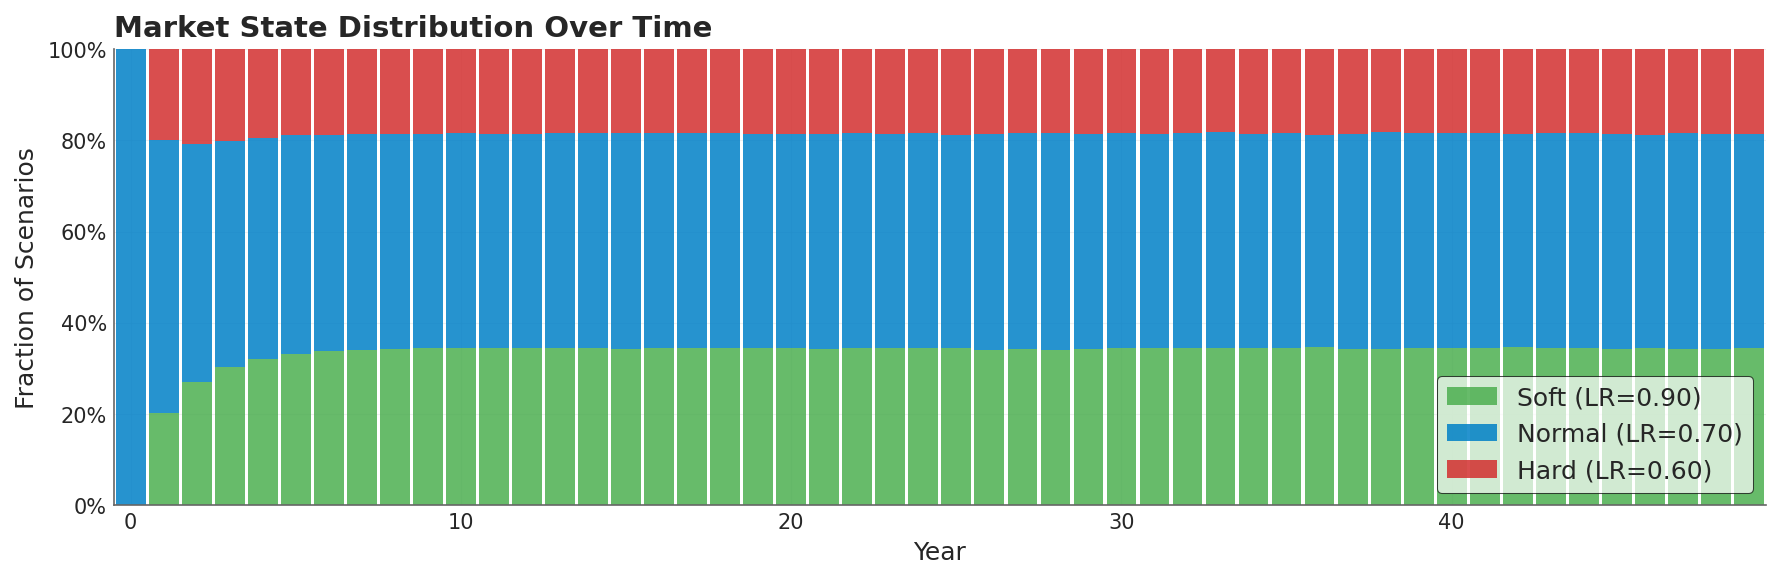

In [9]:
set_wsj_style()

# Fraction of scenarios in each state per year
state_fracs = np.zeros((3, N_YEARS))
for s in range(3):
    state_fracs[s] = (market_states == s).mean(axis=0)

MARKET_COLORS = [WSJ_COLORS.get('green', '#2ca02c'),
                 WSJ_COLORS.get('blue', '#1f77b4'),
                 WSJ_COLORS.get('red', '#d62728')]

fig, ax = plt.subplots(figsize=(12, 4), dpi=150)
years = np.arange(N_YEARS)
bottom = np.zeros(N_YEARS)
for s in range(3):
    ax.bar(years, state_fracs[s], bottom=bottom, color=MARKET_COLORS[s],
           label=f"{MARKET_NAMES[s]} (LR={MARKET_LR[s]:.2f})", width=0.9, alpha=0.85)
    bottom += state_fracs[s]
ax.set_xlabel("Year")
ax.set_ylabel("Fraction of Scenarios")
ax.set_title("Market State Distribution Over Time", fontweight='bold', loc='left')
ax.legend(fontsize=12, loc='lower right', facecolor='white',
           edgecolor='black', framealpha=0.7, fancybox=True, frameon=True)
ax.set_xlim(-0.5, N_YEARS - 0.5)
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.tight_layout()
plt.savefig("cache/plot_01_market_states.png", dpi=150, bbox_inches='tight')
plt.show()

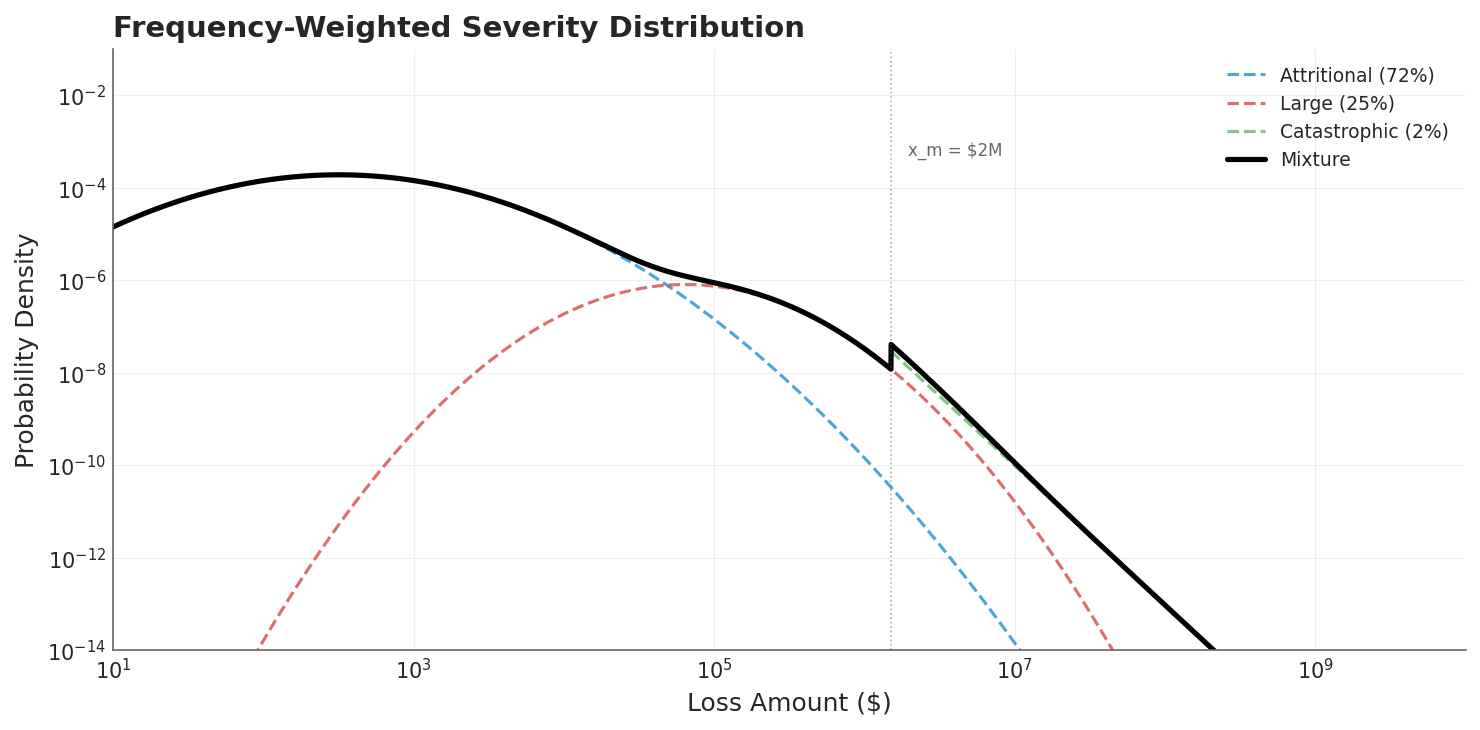

In [10]:
set_wsj_style()

xg = np.logspace(0, 10, 8000)
freq_total = ATTR_BASE_FREQ + LG_BASE_FREQ + CAT_BASE_FREQ
w_a = ATTR_BASE_FREQ / freq_total
w_l = LG_BASE_FREQ   / freq_total
w_c = CAT_BASE_FREQ  / freq_total

pdf_a = sp_lognorm.pdf(xg, s=attr_sig, scale=np.exp(attr_mu))
pdf_l = sp_lognorm.pdf(xg, s=lg_sig,   scale=np.exp(lg_mu))
cat_mask = xg >= CAT_SEV_XM
pdf_c = np.where(cat_mask,
                 CAT_SEV_ALPHA * CAT_SEV_XM**CAT_SEV_ALPHA * xg**(-CAT_SEV_ALPHA - 1), 0.0)
pdf_mix = w_a * pdf_a + w_l * pdf_l + w_c * pdf_c

fig, ax = plt.subplots(figsize=(10, 5), dpi=150)
ax.loglog(xg, w_a * pdf_a, color=COLOR_SEQUENCE[0], lw=1.5, ls='--', alpha=0.7,
          label=f"Attritional ({w_a:.0%})")
ax.loglog(xg, w_l * pdf_l, color=COLOR_SEQUENCE[1], lw=1.5, ls='--', alpha=0.7,
          label=f"Large ({w_l:.0%})")
ax.loglog(xg[cat_mask], w_c * pdf_c[cat_mask], color=COLOR_SEQUENCE[2], lw=1.5,
          ls='--', alpha=0.7, label=f"Catastrophic ({w_c:.0%})")
ax.loglog(xg, pdf_mix, color=WSJ_COLORS.get('black', 'k'), lw=2.5, label="Mixture")
ax.axvline(CAT_SEV_XM, color=WSJ_COLORS.get('gray', 'gray'), ls=':', alpha=0.5, lw=0.8)
ax.text(CAT_SEV_XM * 1.3, 5e-4, f"x_m = ${CAT_SEV_XM/1e6:.0f}M", fontsize=8,
        color=WSJ_COLORS.get('gray', 'gray'))
ax.set_xlim(10, 1e10);  ax.set_ylim(1e-14, 1e-1)
ax.set_xlabel("Loss Amount ($)")
ax.set_ylabel("Probability Density")
ax.set_title("Frequency-Weighted Severity Distribution", fontweight='bold', loc='left')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("cache/plot_02_severity_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

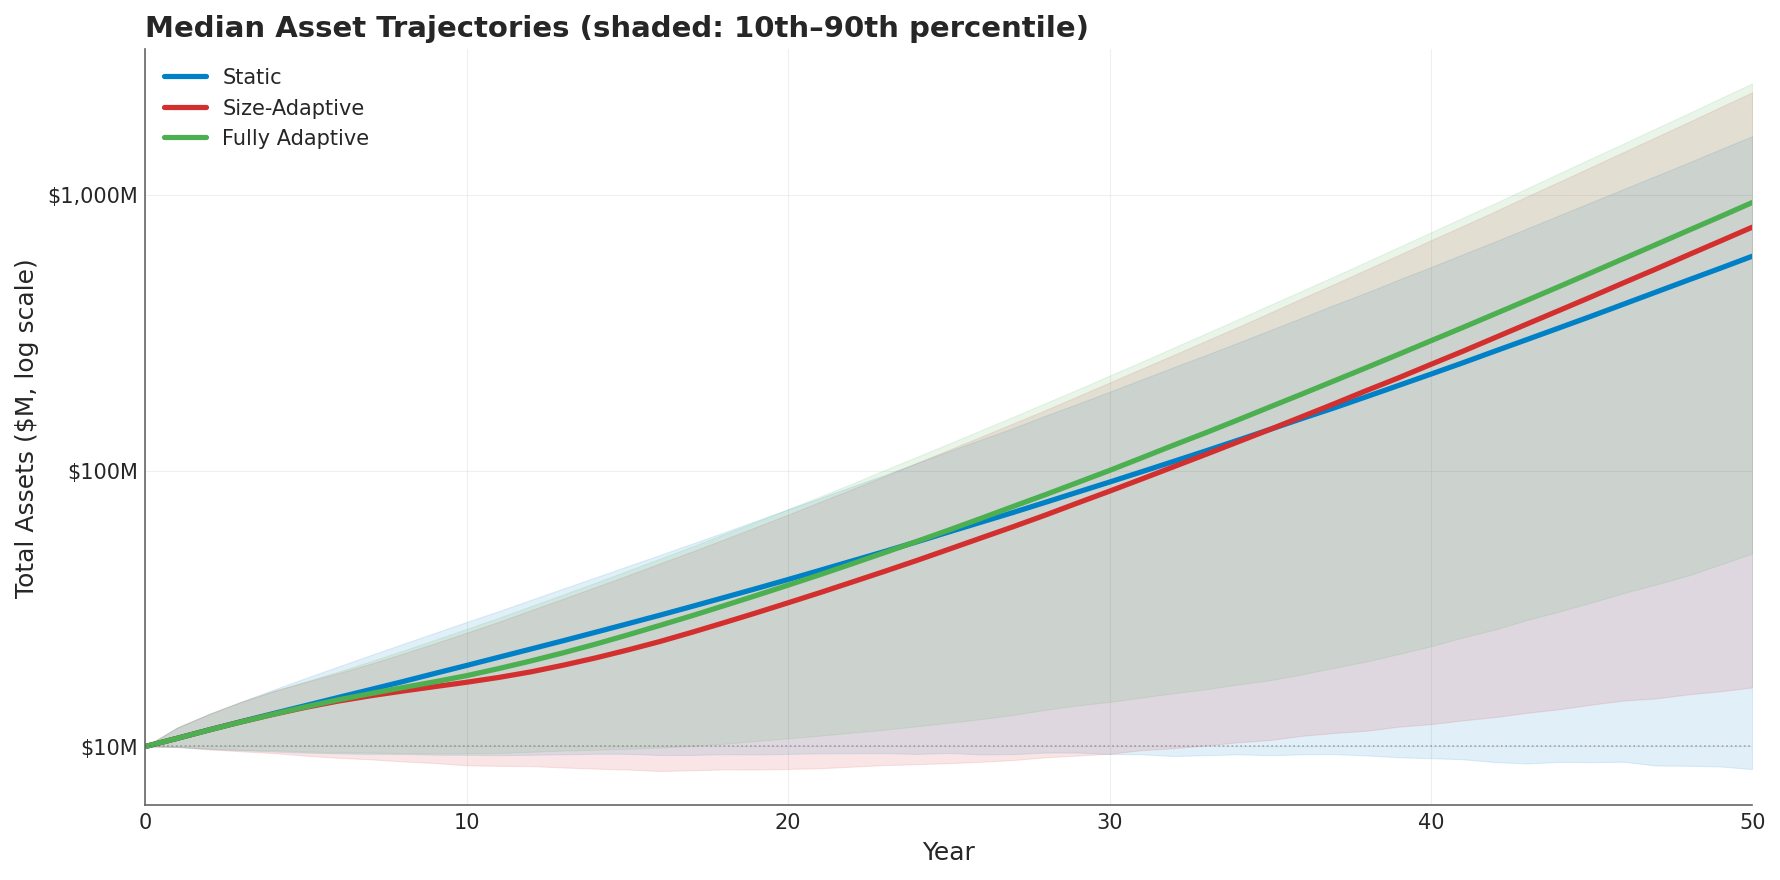

In [11]:
set_wsj_style()

fig, ax = plt.subplots(figsize=(12, 6), dpi=150)
t_axis = np.arange(N_YEARS + 1)

for si in range(3):
    p = paths[si]
    med = np.median(p, axis=0)
    p10 = np.percentile(p, 10, axis=0)
    p90 = np.percentile(p, 90, axis=0)
    ax.semilogy(t_axis, med / 1e6, color=STRAT_COLORS[si], lw=2.5,
                label=STRAT_NAMES[si])
    ax.fill_between(t_axis, np.maximum(p10, 1) / 1e6, p90 / 1e6,
                    color=STRAT_COLORS[si], alpha=0.12)

ax.axhline(INITIAL_ASSETS / 1e6, color=WSJ_COLORS.get('gray', 'gray'),
           ls=':', lw=0.8, alpha=0.5)
ax.set_xlabel("Year")
ax.set_ylabel("Total Assets ($M, log scale)")
ax.set_title("Median Asset Trajectories (shaded: 10th\u201390th percentile)",
             fontweight='bold', loc='left')
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"${x:,.0f}M" if x >= 1 else f"${x*1000:,.0f}K"))
ax.set_xlim(0, N_YEARS)
plt.tight_layout()
plt.savefig("cache/plot_03_asset_paths.png", dpi=150, bbox_inches='tight')
plt.show()

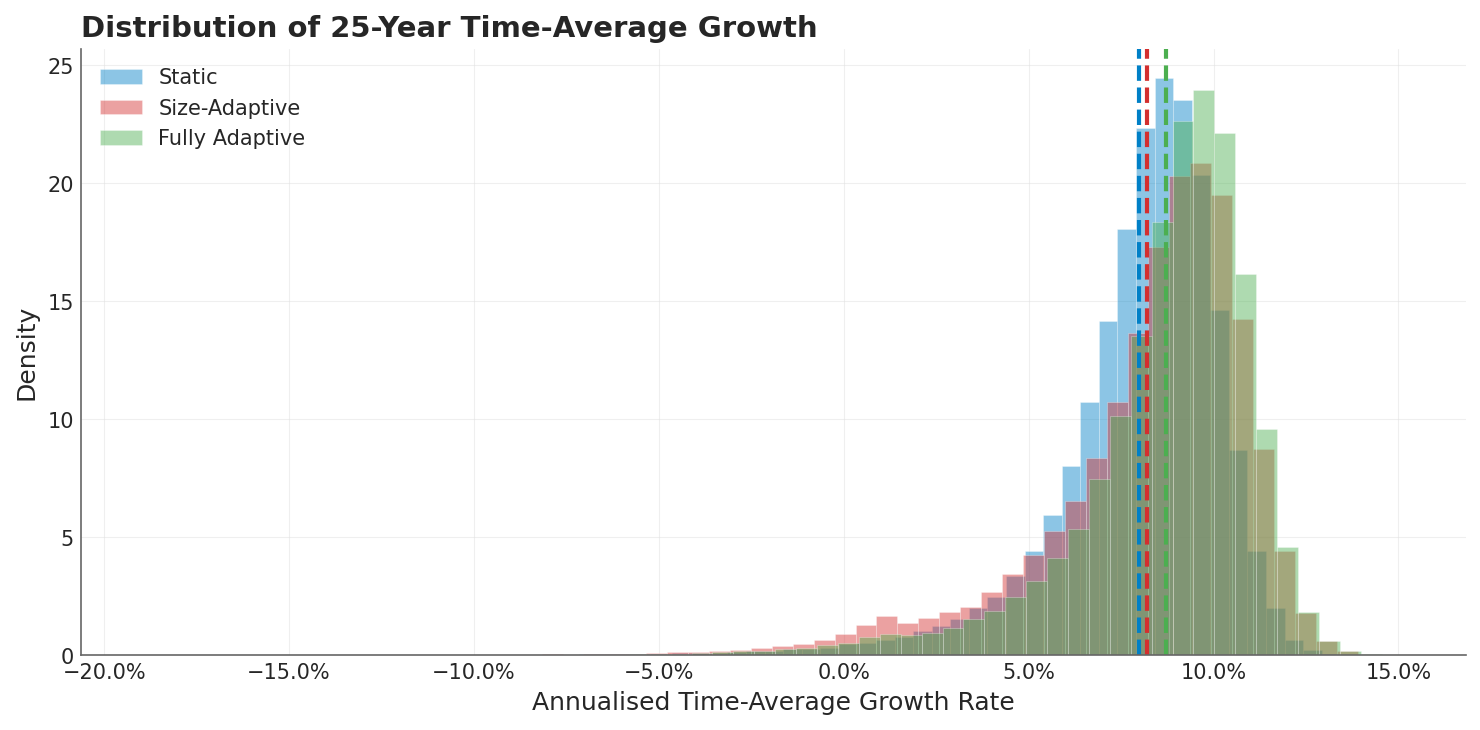

In [12]:
set_wsj_style()

fig, ax = plt.subplots(figsize=(10, 5), dpi=150)

for si in range(3):
    fw = paths[si, :, -1]
    lg = np.log(np.maximum(fw, 1) / INITIAL_ASSETS) / N_YEARS
    alive = fw > 0
    data = lg[alive]
    ax.hist(data, bins=60, density=True, alpha=0.45,
            color=STRAT_COLORS[si], label=STRAT_NAMES[si], edgecolor='white', lw=0.3)
    ax.axvline(np.mean(data), color=STRAT_COLORS[si], ls='--', lw=2)

ax.set_xlabel("Annualised Time-Average Growth Rate")
ax.set_ylabel("Density")
ax.set_title("Distribution of 25-Year Time-Average Growth",
             fontweight='bold', loc='left')
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.tight_layout()
plt.savefig("cache/plot_04_growth_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

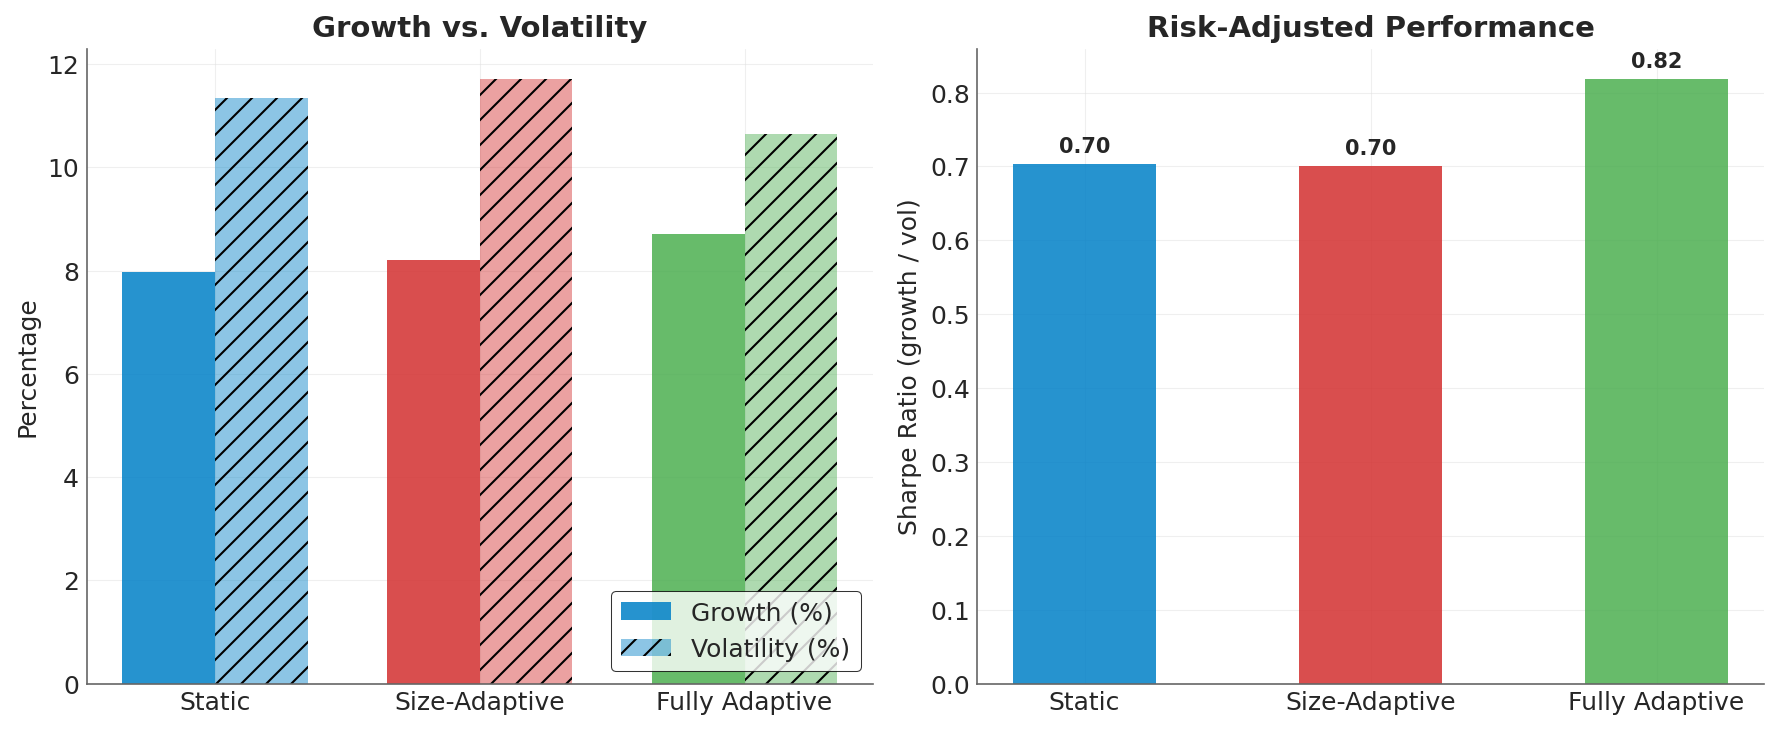

In [13]:
set_wsj_style()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), dpi=150)

# Left: Time-average growth and volatility bars
ta_growth_vals = []
vol_vals = []
sharpe_vals = []

for si in range(3):
    fw = paths[si, :, -1]
    alive = fw > 0
    lg = np.log(np.maximum(fw, 1) / INITIAL_ASSETS) / N_YEARS
    ar = np.diff(np.log(np.maximum(paths[si], 1)), axis=1)
    ta = np.mean(lg[alive]) if alive.any() else 0
    vol = np.std(ar[alive].ravel()) if alive.any() else 0
    ta_growth_vals.append(ta)
    vol_vals.append(vol)
    sharpe_vals.append(ta / vol if vol > 0 else 0)

x = np.arange(3)
w = 0.35
bars1 = ax1.bar(x - w/2, [g * 100 for g in ta_growth_vals], w,
                color=[STRAT_COLORS[i] for i in range(3)], alpha=0.85,
                label='Growth (%)')
bars2 = ax1.bar(x + w/2, [v * 100 for v in vol_vals], w,
                color=[STRAT_COLORS[i] for i in range(3)], alpha=0.45,
                label='Volatility (%)', hatch='//')
ax1.set_xticks(x)
ax1.set_xticklabels(STRAT_NAMES, fontsize=12)
ax1.set_ylabel("Percentage")
ax1.tick_params(axis='y', labelsize=12)
ax1.set_title("Growth vs. Volatility", fontweight='bold', loc='center')

ax1.legend(fontsize=12, loc='lower right', facecolor='white',
           edgecolor='black', framealpha=0.8, fancybox=True, frameon=True)

# Right: Sharpe ratio
bars3 = ax2.bar(x, sharpe_vals, 0.5,
                color=[STRAT_COLORS[i] for i in range(3)], alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels(STRAT_NAMES, fontsize=12)
ax2.set_ylabel("Sharpe Ratio (growth / vol)")
ax2.tick_params(axis='y', labelsize=12)
ax2.set_title("Risk-Adjusted Performance", fontweight='bold', loc='center')
for bar, val in zip(bars3, sharpe_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{val:.2f}", ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig("cache/plot_05_sharpe_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

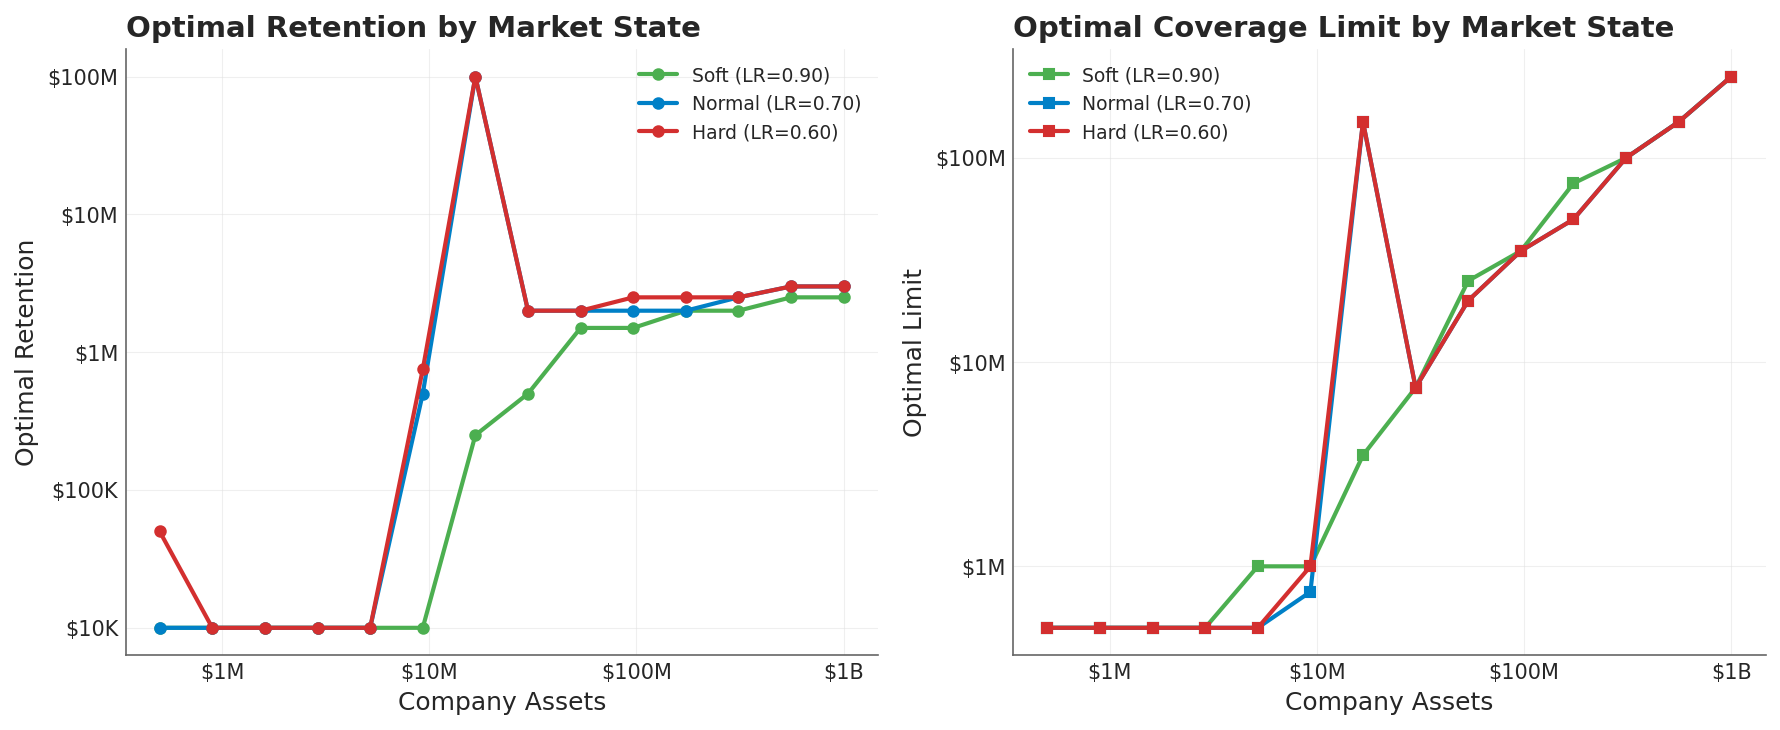

In [14]:
set_wsj_style()

def dollar_fmt(x, pos):
    if x >= 1e9:  return f'${x/1e9:.0f}B'
    elif x >= 1e6: return f'${x/1e6:.0f}M'
    elif x >= 1e3: return f'${x/1e3:.0f}K'
    return f'${x:.0f}'

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), dpi=150)

for s_idx in range(3):
    ax1.loglog(WEALTH_GRID, optimal_ret[s_idx],
               'o-', color=MARKET_COLORS[s_idx], lw=2, ms=5,
               label=f"{MARKET_NAMES[s_idx]} (LR={MARKET_LR[s_idx]:.2f})")
    ax2.loglog(WEALTH_GRID, optimal_lim[s_idx],
               's-', color=MARKET_COLORS[s_idx], lw=2, ms=5,
               label=f"{MARKET_NAMES[s_idx]} (LR={MARKET_LR[s_idx]:.2f})")

ax1.set_xlabel("Company Assets")
ax1.set_ylabel("Optimal Retention")
ax1.set_title("Optimal Retention by Market State", fontweight='bold', loc='left')
ax1.legend(fontsize=9)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(dollar_fmt))
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(dollar_fmt))

ax2.set_xlabel("Company Assets")
ax2.set_ylabel("Optimal Limit")
ax2.set_title("Optimal Coverage Limit by Market State", fontweight='bold', loc='left')
ax2.legend(fontsize=9)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(dollar_fmt))
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(dollar_fmt))

plt.tight_layout()
plt.savefig("cache/plot_06_optimal_strategy.png", dpi=150, bbox_inches='tight')
plt.show()

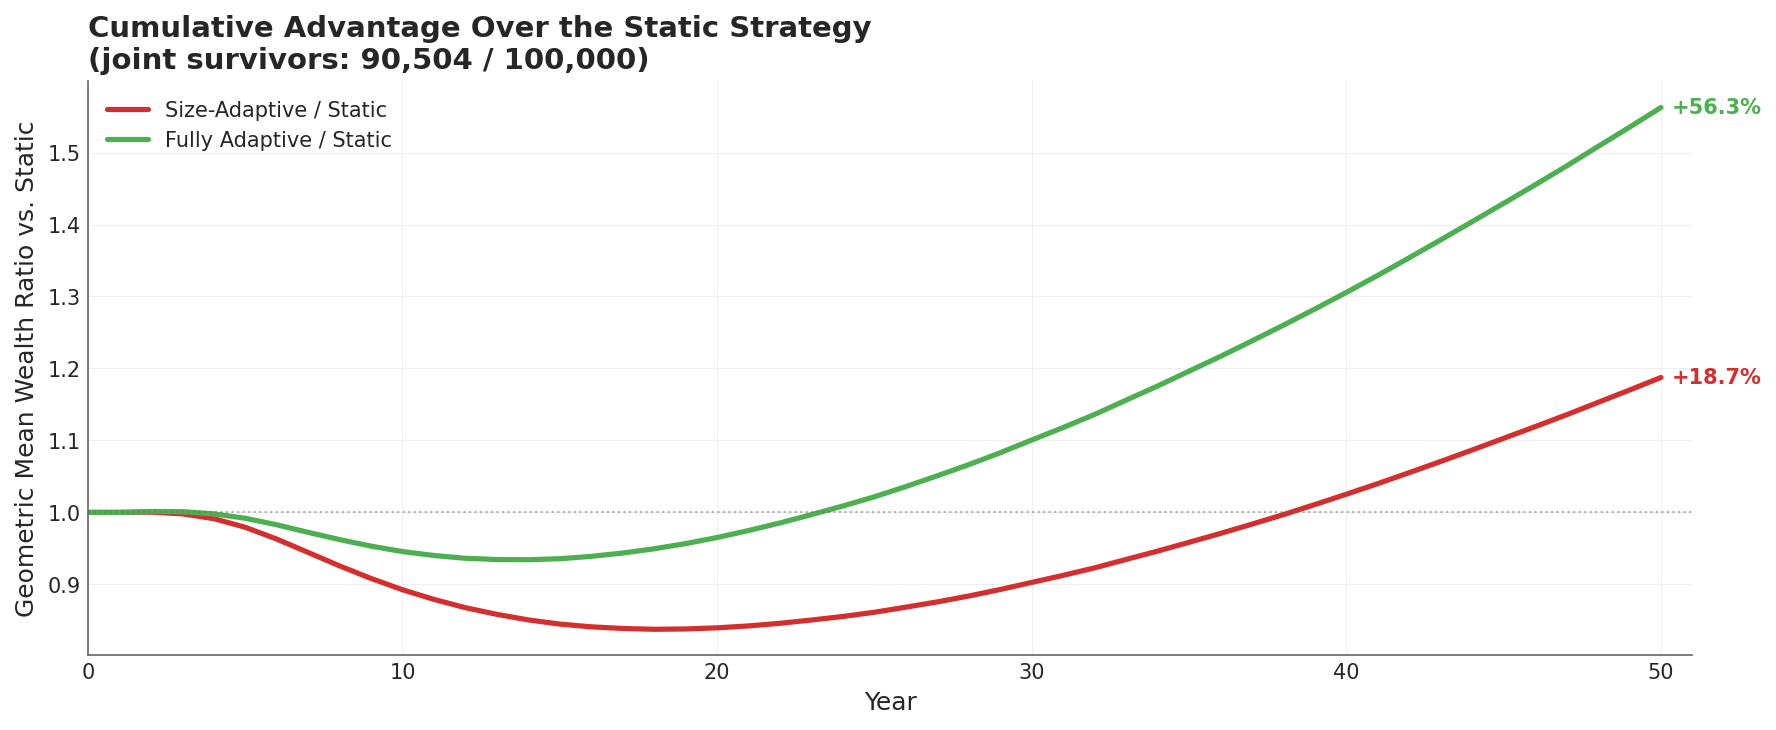

In [15]:
set_wsj_style()

fig, ax = plt.subplots(figsize=(12, 5), dpi=150)

# Condition on JOINT survival so the metric measures pure growth
# differences, not survival-rate differences.  Without this filter,
# dead firms (log(max(0,1))=0 ≈ 21 log-units below survivors) inflate
# the "advantage" of strategies with even slightly higher survival.
all_survive = np.all(paths[:, :, -1] > 0, axis=0)  # (N_SCENARIOS,)
n_joint = all_survive.sum()

log_static = np.mean(np.log(np.maximum(paths[0, all_survive, :], 1)), axis=0)

for si in [1, 2]:
    log_si = np.mean(np.log(np.maximum(paths[si, all_survive, :], 1)), axis=0)
    advantage = np.exp(log_si - log_static)  # geometric mean wealth ratio
    ax.plot(t_axis, advantage, color=STRAT_COLORS[si], lw=2.5,
            label=f"{STRAT_NAMES[si]} / Static")
    # Annotate final value
    pct = (advantage[-1] - 1) * 100
    ax.annotate(f"+{pct:.1f}%", xy=(N_YEARS, advantage[-1]),
                xytext=(5, 0), textcoords='offset points', fontsize=10,
                fontweight='bold', color=STRAT_COLORS[si], va='center')

ax.axhline(1.0, color=WSJ_COLORS.get('gray', 'gray'), ls=':', lw=1, alpha=0.5)
ax.set_xlabel("Year")
ax.set_ylabel("Geometric Mean Wealth Ratio vs. Static")
ax.set_title("Cumulative Advantage Over the Static Strategy"
             f"\n(joint survivors: {n_joint:,} / {N_SCENARIOS:,})",
             fontweight='bold', loc='left')
ax.legend(fontsize=10, loc='upper left')
ax.set_xlim(0, N_YEARS + 1)
plt.tight_layout()
plt.savefig("cache/plot_07_cumulative_advantage.png", dpi=150, bbox_inches='tight')
plt.show()

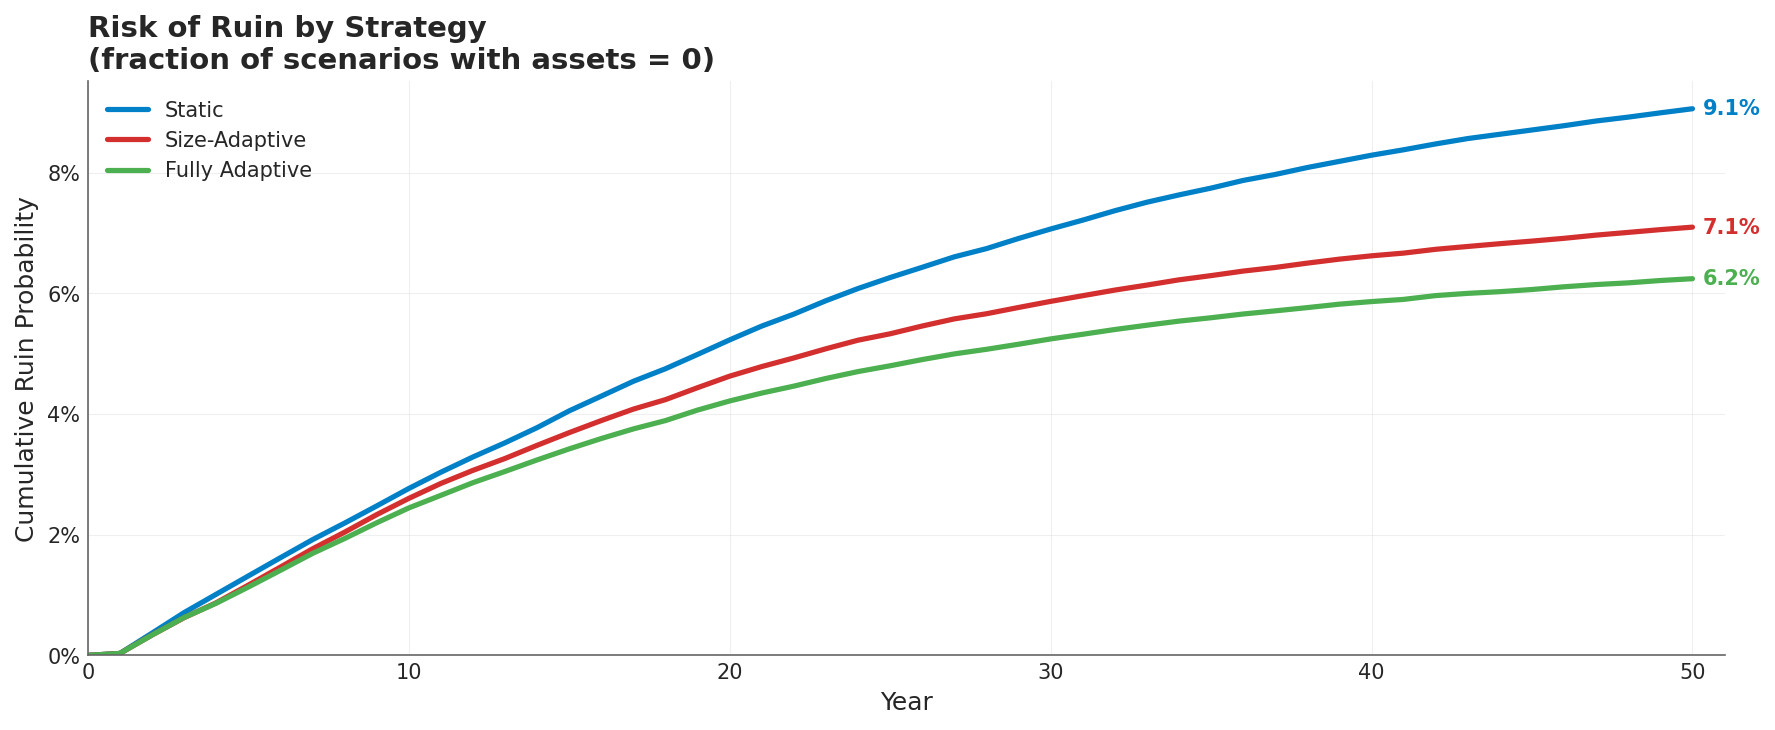

In [16]:
set_wsj_style()

fig, ax = plt.subplots(figsize=(12, 5), dpi=150)

for si in range(3):
    # Cumulative ruin: fraction of scenarios bankrupt by each year
    # Ruin is absorbing (assets = 0 stays 0), so this is monotonically increasing
    ruin_by_t = 1.0 - np.mean(paths[si, :, :] > 0, axis=0)  # (N_YEARS+1,)
    ax.plot(t_axis, ruin_by_t, color=STRAT_COLORS[si], lw=2.5,
            label=STRAT_NAMES[si])
    # Annotate final ruin probability
    ax.annotate(f"{ruin_by_t[-1]:.1%}", xy=(N_YEARS, ruin_by_t[-1]),
                xytext=(5, 0), textcoords='offset points', fontsize=10,
                fontweight='bold', color=STRAT_COLORS[si], va='center')

ax.set_xlabel("Year")
ax.set_ylabel("Cumulative Ruin Probability")
ax.set_title("Risk of Ruin by Strategy\n(fraction of scenarios with assets = 0)",
             fontweight='bold', loc='left')
ax.legend(fontsize=10, loc='upper left')
ax.set_xlim(0, N_YEARS + 1)
ax.set_ylim(bottom=0)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=0))
plt.tight_layout()
plt.savefig("cache/plot_08_risk_of_ruin.png", dpi=150, bbox_inches='tight')
plt.show()

## References

1. **Hamilton, J. D.** (1989). A new approach to the economic analysis of nonstationary time series and the business cycle. *Econometrica*, 57(2),   357–384. https://doi.org/10.2307/19125592.
2. **Cummins, J. D., & Outreville, J. F.** (1987). An international analysis   of underwriting cycles in property-liability insurance. *Journal of Risk   and Insurance*, 54(2), 246–262. https://doi.org/10.2307/253226